In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [7]:
df=pd.read_csv('RESULT.csv')

In [8]:
df.head()

,url,type,0,1,2,3,4,5,6,7,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,https://www.beroyalairforce.tumblr.com/,0,4.536286,7.701725,2.751506,1.961069,-5.422390,-5.938502,4.570453,0.353025,...,-5.365789,0.661055,1.072909,16.016500,6.886988,9.750399,3.833262,-0.136868,-4.483562,-2.508195
1,https://www.colts.com/,0,-1.359303,4.204414,1.183668,3.295020,1.918070,-0.712786,3.155585,-6.198840,...,-3.389442,-0.089229,3.035681,17.113449,2.682641,22.024849,8.846536,4.660522,-0.502236,-9.381823
2,http://printfastvegas.com/create/GOOGLENEWW/GO...,1,0.373590,-0.286500,3.710058,-2.773937,-1.941806,6.024790,6.237419,2.208217,...,-10.004152,-1.861899,-0.639365,5.958819,4.518531,21.813799,-1.802695,-1.046291,2.440579,1.401767
3,http://neaindustrias.com/Image/Googleddrive/Go...,1,3.711474,3.619465,2.650334,-0.478569,-5.177958,5.208449,3.140607,-0.637553,...,-3.650945,0.683283,-0.408646,7.276477,2.935656,23.817551,-3.225528,2.555102,-0.073119,-0.606580
4,http://forestnice.com/download/6C156D35.zip,1,1.006960,0.770139,1.770723,-2.965633,0.805726,-2.455025,-1.636339,-4.910818,...,3.631575,-5.442421,-10.027542,9.492413,6.449296,17.067564,-0.603650,-2.505689,0.301159,-9.932166


In [9]:
df.describe()

,type,0,1,2,3,4,5,6,7,8,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,...,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.500000,0.882210,1.289594,0.196322,0.035230,2.261339,1.016148,-0.804567,1.108774,-0.594632,...,-0.281970,-4.226298,-2.068584,7.256444,2.332808,18.279081,3.192279,-0.369966,1.378403,-2.867617
std,0.500002,3.334864,3.510477,3.342879,3.831729,3.507168,4.861266,3.952569,3.330430,3.361804,...,4.337176,3.777940,3.352802,5.834170,3.493551,10.262455,4.278732,4.144600,4.402003,4.457192
min,0.000000,-18.214502,-21.822687,-18.171127,-20.779150,-14.923450,-22.555340,-14.981736,-14.496495,-15.942041,...,-18.962963,-21.492039,-19.395571,-25.741135,-15.154643,-52.866802,-17.715858,-18.185703,-19.597208,-22.989132
25%,0.000000,-1.341718,-0.936393,-1.937472,-2.583845,-0.098888,-2.447860,-3.741165,-1.053170,-2.752083,...,-3.259664,-6.938211,-4.216873,3.559355,0.072314,12.859171,0.255373,-2.945161,-1.672344,-5.591863
50%,0.500000,0.990312,1.294246,0.283948,0.125113,2.055262,0.679789,-1.073017,1.131930,-0.685043,...,0.162892,-4.124447,-1.894434,7.333677,2.386666,18.764170,3.047523,-0.229408,1.515002,-2.586912
75%,1.000000,3.184255,3.627597,2.390134,2.628376,4.518065,4.364866,2.029438,3.228183,1.477299,...,2.895061,-1.585923,0.296151,11.094864,4.670670,24.867005,5.845644,2.408318,4.505167,0.042250
max,1.000000,17.267864,17.702398,15.692766,20.054699,19.287682,21.631102,17.084831,17.915497,18.382504,...,17.266996,13.679637,14.150562,33.440895,17.868174,53.949409,23.388260,17.758709,18.715748,15.785110


In [5]:
df.info

<bound method DataFrame.info of                                                       url  type          0  \
0                 https://www.beroyalairforce.tumblr.com/     0   4.536286   
1                                  https://www.colts.com/     0  -1.359303   
2       http://printfastvegas.com/create/GOOGLENEWW/GO...     1   0.373590   
3       http://neaindustrias.com/Image/Googleddrive/Go...     1   3.711474   
4             http://forestnice.com/download/6C156D35.zip     1   1.006960   
...                                                   ...   ...        ...   
149995  http://manaveeyamnews.com/css/sed/GD/PI/e8c436...     1   4.173977   
149996  http://sacurity-info-notif2018.000webhostapp.c...     1  -2.158694   
149997                          http://kinecc8787.esy.es/     1   2.643696   
149998  http://fellinio.cf/Uk9HSwQAWEsGS1FPUVJbWwtdXlg...     1 -10.212866   
149999  http://www.bibwebshop.com/RES1011/m1cros0fts/i...     1  -1.045579   

               1         2     

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Columns: 4098 entries, url to 4095
dtypes: float64(4096), int64(1), object(1)
memory usage: 4.6+ GB


In [7]:
df.dtypes

url      object
type      int64
0       float64
1       float64
2       float64
         ...   
4091    float64
4092    float64
4093    float64
4094    float64
4095    float64
Length: 4098, dtype: object

In [10]:
X = df.iloc[:, 2:].values
y = df.iloc[:, 1].values

In [11]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [31]:
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

In [32]:
# Define the model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

E:\PARTH\FinalProject2025\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [34]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
3282/3282 ━━━━━━━━━━━━━━━━━━━━ 69s 16ms/step - accuracy: 0.9508 - loss: 0.1461 - val_accuracy: 0.9830 - val_loss: 0.0534
Epoch 2/10
3282/3282 ━━━━━━━━━━━━━━━━━━━━ 54s 16ms/step - accuracy: 0.9713 - loss: 0.0940 - val_accuracy: 0.9836 - val_loss: 0.0515
Epoch 3/10
3282/3282 ━━━━━━━━━━━━━━━━━━━━ 53s 16ms/step - accuracy: 0.9768 - loss: 0.0816 - val_accuracy: 0.9854 - val_loss: 0.0478
Epoch 4/10
3282/3282 ━━━━━━━━━━━━━━━━━━━━ 51s 16ms/step - accuracy: 0.9802 - loss: 0.0691 - val_accuracy: 0.9851 - val_loss: 0.0487
Epoch 5/10
3282/3282 ━━━━━━━━━━━━━━━━━━━━ 50s 15ms/step - accuracy: 0.9787 - loss: 0.0715 - val_accuracy: 0.9857 - val_loss: 0.0449
Epoch 6/10
3282/3282 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - accuracy: 0.9818 - loss: 0.0630 - val_accuracy: 0.9867 - val_loss: 0.0455
Epoch 7/10
3282/3282 ━━━━━━━━━━━━━━━━━━━━ 44s 13ms/step - accuracy: 0.9824 - loss: 0.0621 - val_accuracy: 0.9864 - val_loss: 0.0450
Epoch 8/10
3282/3282 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - accuracy: 0.9838 -

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Model Accuracy: 0.9874

Confusion Matrix:
[[22245   176]
 [  389 22190]]


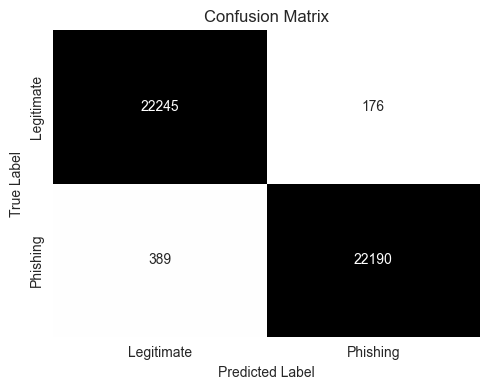


Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99     22421
    Phishing       0.99      0.98      0.99     22579

    accuracy                           0.99     45000
   macro avg       0.99      0.99      0.99     45000
weighted avg       0.99      0.99      0.99     45000



In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.6).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False,
            xticklabels=["Legitimate", "Phishing"],
            yticklabels=["Legitimate", "Phishing"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"]))


In [23]:
model.save("test3.h5")

In [35]:
import numpy as np
from tensorflow.keras.models import load_model
from urllib.parse import urlparse
from sklearn.preprocessing import StandardScaler
import ollama

model = load_model("test1.h5")

In [36]:
def tokenize_url(url):
    parsed = urlparse(url)
    return {
        "protocol": parsed.scheme,
        "domain": parsed.netloc,
        "path": parsed.path,
        "num_query_params": len(parsed.query.split("&")) if parsed.query else 0,
        "has_login": 1 if "login" in parsed.path.lower() or "signin" in parsed.path.lower() else 0,
        "has_ip": 1 if any(char.isdigit() for char in parsed.netloc) else 0,
    }

In [37]:
def get_embedding(text):
    response = ollama.embeddings(model="mistral", prompt=text)
    return response['embedding']

In [38]:
def test_model(url):
    tokenized = tokenize_url(url)
    text_for_embedding = tokenized["domain"] + " " + tokenized["path"]
    embedding = get_embedding(text_for_embedding)
    embedding = np.array(embedding).reshape(1, -1)
    embedding = scaler.transform(embedding)
    embedding = embedding.reshape(1, 1, -1)

    prediction = model.predict(embedding)[0][0]
    print(prediction)
    result = "Phishing" if prediction > 0.6 else "Legitimate"
    print(f"Prediction: {result} (Confidence: {prediction:.4f})")

In [44]:
user_url = input("Enter a URL to check: ")
test_model(user_url)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
0.03193248
Prediction: Legitimate (Confidence: 0.0319)
